## Image Representations

<h2><b>What is the meaning of 'representations of images'?</b></h2>

An image representation refers to the process of translating raw, high-dimensional visual data (like tens of thousands of RGB pixel values) into a compressed, abstract, or more useful mathematical form.
Fundamentally, image representation is rooted in dimensionality reduction. While raw image data $x$ exists in a massive, high-dimensional coordinate system, realistic images (like faces or natural scenes) only occupy a tiny subset or "manifold" of that space. Creating a representation means finding a "low-dimensional (or hidden) representation $h$, which can approximately explain the data $x$, so that $x \approx f[h,\theta]$".

<h3>What is achieved by image representation?</h3>

1. <i>Dimensionality reduction</i> : From thousands of rows of RGB values, we come down to few hundreds of rows of representation.
2. <i> A Compact Summary of Critical Information</i>: A representation serves as a "highly compact representation" that summarizes an image region while retaining the "critical information about the image appearance and layout".
3. <i> A Method to Filter Out Irrelevant Variations </i>: In real-world computer vision, raw RGB values constantly fluctuate due to factors that have nothing to do with the actual object, such as changes in ambient lighting, camera gain, or slight shifts in pose.
4. <i> An Intermediate Stepping Stone for Inference </i>: Representations act as an "intermediate representation for inferring higher-level properties".

<h2><b>The Dataset: ImageNet</b></h2>

**ImageNet** is a massive, foundational visual database designed specifically to support visual object recognition and computer vision research. It serves as a comprehensive "visual dictionary" for computers and has been instrumental in advancing deep learning models.

* **Scale and Scope:** The full dataset (sometimes referred to as ImageNet-21K) contains more than 14 million images that have been hand-annotated.
* **Organization:** It is structured according to the WordNet lexical hierarchy, where each node or concept (called a "synset") is depicted by hundreds or thousands of images. The full dataset contains over 20,000 distinct categories, ranging from specific dog breeds to everyday objects like balloons or strawberries.
* **Annotation:** The images were scraped from search engines and then rigorously human-annotated using Amazon's Mechanical Turk platform to verify the presence of specific objects. Over one million of these images also include object-level bounding boxes to show exactly where the object is located.

Working on entire ImageNet dataset is both laborious and unnecessary. Therefore, this study of creating representations is done on a subset of ImageNet. A 100,000 images were sampled at random from the dataset and were subsequently split into training, validation and test sets in the ratio of 8:1:1 respectively.

<h2><b>The Architecture: Convolutional Autoencoder</b></h2>

The ImageNet dataset is vast and it varies greatly. Hence the ideal architecture to encode the image is a **Convolutional Autoencoder** where stacks of <code>nn.Conv2d</code> and <code>nn.MaxPool2d</code> layers. Each step will increase the number of feature channels while slicing the spatial dimensions ($H \times W$) in half, squeezing the image down into your dense, low-dimensional latent representation.

The same network can later function as a decoder to extract images from the representations.

<h3><b>The Pipeline</b></h3>

* **1. Dataset:** 100k random ImageNet images, split 8:1:1 (80k Train, 10k Val, 10k Test).
* **2. Pre-processing:** Resize all images to a uniform resolution (e.g., $64 \times 64$), convert to PyTorch tensors, and normalize the RGB channels.
* **3. Architecture:** An hourglass design. The **Encoder** (`Conv2d` + `MaxPool`) compresses images into a dense latent representation. The **Decoder** (`ConvTranspose2d`) reconstructs the representation back into pixels.
* **4. Training & Validation:** Optimize using **MSE Loss** (measuring pixel reconstruction error). Monitor validation loss after each epoch to trigger **Early Stopping** and prevent overfitting.



## <b>Data Loading and pre-processing</b>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# setting up seed
seed = 42
torch.manual_seed(seed=seed)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(42)

# 4. Force PyTorch to use deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seeds locked to {seed}. Training is now reproducible.")

Random seeds locked to 42. Training is now reproducible.


In [2]:
# set up the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Subset, dataloader

In [3]:
# 1. define the transformation
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the Tiny ImageNet dataset from Hugging Face
from datasets import load_dataset
ds = load_dataset("zh-plus/tiny-imagenet")

# 3. Simple random splits
splits = ds["train"].train_test_split(test_size=20000, seed=42)
train_dataset = splits["train"]  # 80,000 random images

val_test_splits = splits["test"].train_test_split(test_size=10000, seed=42)
val_dataset = val_test_splits["train"]  # 10,000 random images
test_dataset = val_test_splits["test"]   # Remaining 10,000 random images

# 4. Define the preprocessing transform function to prepare 'pixel_values'
def preprocess(examples):
    examples["pixel_values"] = [transform(img.convert("RGB")) for img in examples["image"]]
    return examples

# Apply the transform dynamically to each split
train_dataset.set_transform(preprocess)
val_dataset.set_transform(preprocess)
test_dataset.set_transform(preprocess)

# 5. Create PyTorch DataLoaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 6. Verify sizes
print(f"Data loading complete:")
print(f" - Train samples: {len(train_dataset)}")
print(f" - Val samples:   {len(val_dataset)}")
print(f" - Test samples:  {len(test_dataset)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

data/train-00000-of-00001-1359597a978bc4(…):   0%|          | 0.00/146M [00:00<?, ?B/s]

data/valid-00000-of-00001-70d52db3c749a9(…):   0%|          | 0.00/14.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Data loading complete:
 - Train samples: 80000
 - Val samples:   10000
 - Test samples:  10000


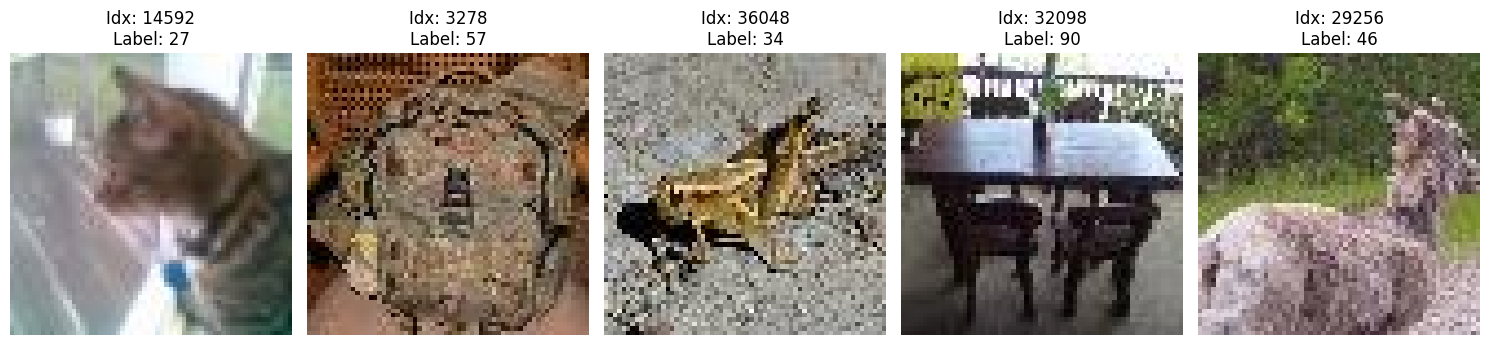

In [19]:
import random

# Set the seed for reproducibility
random.seed(seed)

# 1. Get 5 random indices from the training dataset
random_indices = random.sample(range(len(train_dataset)), 5)

# 2. Denormalization parameters (matching the transform's mean and std)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# 3. Plot the de-normalized images
plt.figure(figsize=(15, 5))
for i, idx in enumerate(random_indices):
    # This retrieves the preprocessed sample (dict containing 'pixel_values' tensor and 'label')
    sample = train_dataset[idx]
    img = sample['pixel_values'].cpu()

    # De-normalize the tensor back to the original pixel range [0, 1]
    img = img * std + mean

    # Convert shape from (C, H, W) to (H, W, C) for Matplotlib
    img = img.numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1) # Clip values to keep them in valid [0, 1] range

    label = sample['label']

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Idx: {idx}\nLabel: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## <h2><b>The Architecture</b></h2>